In [ ]:
#CELL 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


import os
PROJECT_DIR = '/content/drive/MyDrive/MusicGenerationCSE425'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Project directory: {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/MusicGenerationCSE425


In [ ]:
#CELL 1: Setup
!pip install pretty_midi -q
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/MusicGenerationCSE425'
PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'
MODELS_DIR = f'{PROJECT_DIR}/models_saved'
MIDI_OUT_DIR = f'{PROJECT_DIR}/outputs/generated_midis'
PLOTS_DIR = f'{PROJECT_DIR}/outputs/plots'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(MIDI_OUT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [ ]:
#CELL 2: Dataset class
class PianoRollDataset(Dataset):

    def __init__(self, npy_path):
        self.data = np.load(npy_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32)

BATCH_SIZE = 64
train_loader = DataLoader(PianoRollDataset(f"{PROCESSED_DIR}/piano_roll_train.npy"), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(PianoRollDataset(f"{PROCESSED_DIR}/piano_roll_validation.npy"), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("DataLoaders ready")

DataLoaders ready


In [ ]:
#CELL 3: LSTM Autoencoder Architecture
#Encoder: LSTM to latent vector z
#Decoder: z repeated to LSTM
class LSTMEncoder(nn.Module):
    #Encodes a piano-roll window to a fixed-size latent vector. Input:  (batch, T, 88). Output: (batch, latent_dim)
    def __init__(self, input_dim=88, hidden_dim=256, latent_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        #LSTM final hidden state -> latent vector
        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        #x shape:
        _, (h_n, _) = self.lstm(x)

        last_hidden = h_n[-1]
        z = self.fc(last_hidden)
        return z


class LSTMDecoder(nn.Module):
    #Decodes a latent vector z to reconstruct the piano-roll window. Input: (batch, latent_dim) Output: (batch, T, 88) - raw logits (NO sigmoid here :') )
    def __init__(self, latent_dim=64, hidden_dim=256, output_dim=88, seq_len=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.seq_len = seq_len

        #Project latent vector to LSTM hidden-dimension space
        self.fc_in = nn.Linear(latent_dim, hidden_dim)
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        #Project LSTM output
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        #No sigmoid here

    def forward(self, z):
        #z shape: (batch, latent_dim)
        batch_size = z.size(0)


        z_repeated = z.unsqueeze(1).repeat(1, self.seq_len, 1)

        #Initialize hidden state from z
        h0 = self.fc_in(z).unsqueeze(0).repeat(2, 1, 1)
        c0 = torch.zeros_like(h0)

        out, _ = self.lstm(z_repeated, (h0, c0))
        logits = self.fc_out(out)
        return logits


class LSTMAutoencoder(nn.Module):

    def __init__(self, input_dim=88, hidden_dim=256, latent_dim=64, seq_len=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = LSTMEncoder(input_dim, hidden_dim, latent_dim, num_layers, dropout)
        self.decoder = LSTMDecoder(latent_dim, hidden_dim, input_dim, seq_len, num_layers, dropout)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


model = LSTMAutoencoder(input_dim=88, hidden_dim=256, latent_dim=64, seq_len=128, num_layers=2, dropout=0.3).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LSTM Autoencoder ready — Trainable parameters: {total_params:,}")

LSTM Autoencoder ready — Trainable parameters: 1,792,408


In [ ]:
#CELL 4: Focal Loss - handles piano-roll class imbalance

class FocalLoss(nn.Module):
    """Focal Loss for binary classification with class imbalance. Suppresses gradients from easy (silence) cells and amplifies gradients from hard (note) cells.
    FL(p) = -alpha*(1-p)^gamma*log(p)
    Args: alpha: weight for positive class (set > 1 to upweight notes), gamma: focusing parameter (higher = more focus on hard examples)"""

    def __init__(self, alpha=10.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        #Apply sigmoid
        probs = torch.sigmoid(logits)

        #Binary cross-entropy per element
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')

        #Focal modulation: down-weights easy examples
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = (1 - pt) ** self.gamma

        #Apply positive class weighting
        alpha_weight = torch.where(targets == 1, torch.tensor(self.alpha, device=logits.device), torch.tensor(1.0, device=logits.device))
        loss = alpha_weight * focal_weight * bce
        return loss.mean()


criterion = FocalLoss(alpha=10.0, gamma=2.0)
print("Focal Loss ready")

Focal Loss ready


In [ ]:
#CELL 5: Training Loop - Task 1 LSTM Autoencoder
import time

#Hyperparameters
EPOCHS = 80
LR = 1e-3
CLIP_NORM = 1.0

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

train_losses = []
val_losses = []
best_val_loss = float('inf')

print(f"Training LSTM Autoencoder for {EPOCHS} epochs...")
print(f"Device: {DEVICE}, Batch size: {BATCH_SIZE}, LR: {LR}\n")

for epoch in range(1, EPOCHS + 1):
    #Training phase
    model.train()
    total_train_loss = 0.0
    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        x_hat, z = model(batch)
        loss = criterion(x_hat, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    #Validation phase
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            x_hat, _ = model(batch)
            loss = criterion(x_hat, batch)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    #Save best model checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), f"{MODELS_DIR}/task1_ae_best.pth")

    #Print progress every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f}")

print(f"\nTraining complete! Best Val Loss: {best_val_loss:.4f}")

Training LSTM Autoencoder for 80 epochs...
Device: cuda, Batch size: 64, LR: 0.001

Epoch   1/80 | Train Loss: 0.1981 | Val Loss: 0.1779
Epoch  10/80 | Train Loss: 0.0904 | Val Loss: 0.0936
Epoch  20/80 | Train Loss: 0.0674 | Val Loss: 0.0769
Epoch  30/80 | Train Loss: 0.0595 | Val Loss: 0.0729
Epoch  40/80 | Train Loss: 0.0562 | Val Loss: 0.0734
Epoch  50/80 | Train Loss: 0.0519 | Val Loss: 0.0741
Epoch  60/80 | Train Loss: 0.0495 | Val Loss: 0.0760
Epoch  70/80 | Train Loss: 0.0483 | Val Loss: 0.0772
Epoch  80/80 | Train Loss: 0.0479 | Val Loss: 0.0783

Training complete! Best Val Loss: 0.0721


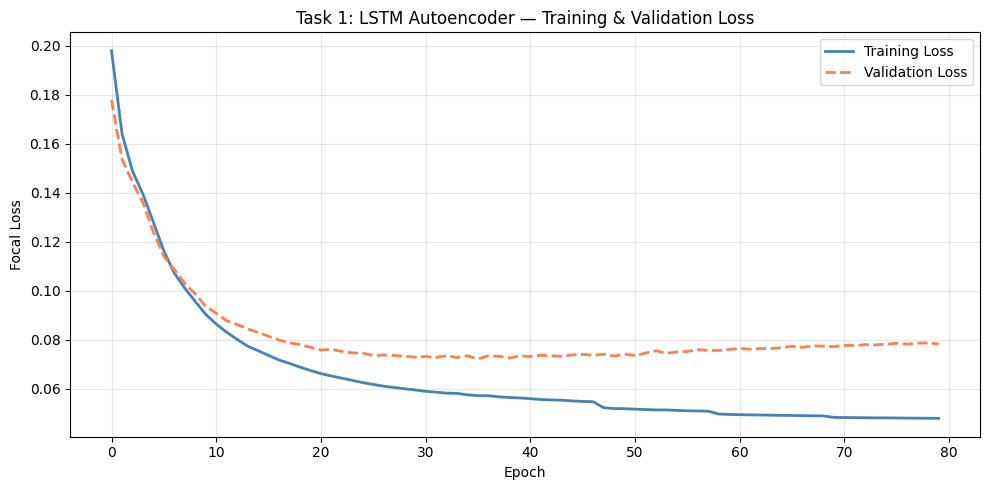

Loss curve saved!


In [ ]:
#CELL 6: Plot Training Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='steelblue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='coral', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Focal Loss')
plt.title('Task 1: LSTM Autoencoder - Training & Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/task1_loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved!")

In [ ]:
#CELL 7: Generate MIDI Samples (Required: 5 samples)
import pretty_midi

#Load best model
model.load_state_dict(torch.load(f"{MODELS_DIR}/task1_ae_best.pth"))
model.eval()

FRAME_RATE = 16
PIANO_MIN = 21
GEN_THRESHOLD = 0.3

def piano_roll_to_midi(piano_roll_binary, frame_rate=16, velocity=80, piano_min=21):
    """Converts a binary (T, 88) piano-roll array to a pretty_midi MIDI object.
    Args:
        piano_roll_binary : numpy array of shape (T, 88), values 0 or 1
        frame_rate: frames per second used in preprocessing
        velocity: MIDI velocity for all notes (0–127)
        piano_min: lowest MIDI pitch (21 = A0 for piano)
    Returns:
        pretty_midi.PrettyMIDI object
    """
    midi = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)

    T, n_pitches = piano_roll_binary.shape
    frame_duration = 1.0 / frame_rate

    for pitch_idx in range(n_pitches):
        pitch = pitch_idx + piano_min
        active = False
        note_start = 0.0

        for t in range(T):
            if piano_roll_binary[t, pitch_idx] == 1 and not active:
                #Note onset
                note_start = t * frame_duration
                active = True
            elif piano_roll_binary[t, pitch_idx] == 0 and active:
                #Note offset
                note_end = t * frame_duration
                if note_end - note_start >= frame_duration:  # min 1 frame duration
                    piano.notes.append(pretty_midi.Note(velocity=velocity, pitch=pitch, start=note_start, end=note_end))
                active = False


        if active:
            note_end = T * frame_duration
            piano.notes.append(pretty_midi.Note(velocity=velocity, pitch=pitch,start=note_start, end=note_end))

    midi.instruments.append(piano)
    return midi


#Generate 5 samples
print("Generating 5 MIDI samples (Task 1)")
with torch.no_grad():
    for i in range(5):

        z = torch.randn(1, 64).to(DEVICE)
        logits = model.decoder(z) #
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()


        piano_roll_binary = (probs > GEN_THRESHOLD).astype(np.float32)


        if piano_roll_binary.sum() < 20:
            print(f"Sample {i+1}: too sparse, regenerating...")
            continue


        midi_obj = piano_roll_to_midi(piano_roll_binary)
        out_path = f"{MIDI_OUT_DIR}/task1_generated_{i+1}.mid"
        midi_obj.write(out_path)
        n_notes = sum(len(inst.notes) for inst in midi_obj.instruments)
        print(f"Sample {i+1}: {n_notes} notes -> {out_path}")

print("Task 1 generation complete!")

Generating 5 MIDI samples (Task 1)
Sample 1: 46 notes -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task1_generated_1.mid
Sample 2: 53 notes -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task1_generated_2.mid
Sample 3: 41 notes -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task1_generated_3.mid
Sample 4: 74 notes -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task1_generated_4.mid
Sample 5: 45 notes -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task1_generated_5.mid
Task 1 generation complete!
